In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from joblib import parallel_backend

import mlflow
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn import metrics

from chesswinnerprediction.baseline.utils import (
    load_train_valid_test,
    get_class_weights,
    setup_mlflow,
    get_worst_params_df,
    estimate_baseline_model,
)
from chesswinnerprediction.baseline.constants import BASELINE_RANDOM_STATE

### MLFlow Setup

In [3]:
setup_mlflow(experiment_name="Ensembles", sklearn_autolog_disable=True)

## Load Data

In [4]:
X_train, y_train, X_valid, y_valid, X_test, y_test = load_train_valid_test()

class_weights = get_class_weights(y_train, verbose=True)

Class weights:
	0-1: 0.6993901117612458
	1-0: 0.6701884649451811
	1/2-1/2: 12.80980153908465


## Random Forest

In [5]:
random_forest_params = {
    "n_estimators": [24, 32, 56],
    "max_depth": [10, 11, 12],
    "max_features": ["sqrt", 0.5],
    "min_samples_split": [1e-6, 1e-5, 1e-4, 1e-3],
    "min_samples_leaf": [1e-6, 1e-5, 1e-4, 1e-3],
    "min_impurity_decrease": [1e-6, 1e-5, 1e-4, 1e-3],
    "min_weight_fraction_leaf": [0.0, 1e-6, 1e-5, 1e-4, 1e-3],
    "max_leaf_nodes": [None, 350, 400, 450, 500],
}

forest_clf = RandomForestClassifier(
    class_weight=class_weights,
    verbose=0,
    n_jobs=-1,
    random_state=BASELINE_RANDOM_STATE,
)

random_search = RandomizedSearchCV(
    estimator=forest_clf,
    param_distributions=random_forest_params,
    n_iter=16,
    cv=5,
    verbose=3,
    random_state=BASELINE_RANDOM_STATE,
    scoring="balanced_accuracy",
    return_train_score=True,
    refit=True,
)

In [ ]:
with mlflow.start_run(run_name="Random Search Forest") as run:
    random_search_run_id = run.info.run_id
    mlflow.log_param("predict_draws", True)
    
    random_search.fit(X_train, y_train)

In [7]:
print(f"Best Score: {random_search.best_score_}")

Best Score: 0.46566621368985894


Let's take a look at the worst parameters.

In [8]:
get_worst_params_df(random_search.cv_results_).head(4)

mean_test_score
param_n_estimators param_min_weight_fraction_leaf param_min_samples_split param_min_samples_leaf param_min_impurity_decrease param_max_leaf_nodes param_max_features param_max_depth                 
32                 0.000001                       0.000001                0.000001               0.001000                    350                  sqrt               11                      0.454671
56                 0.000000                       0.000001                0.000100               0.001000                    400                  sqrt               12                      0.456452
                   0.000010                       0.000010                0.000010               0.001000                    350                  sqrt               11                      0.456452
                                                  0.000100                0.000001               0.000001                    450                  sqrt               12                      0.456475

## Log Best Model

In [9]:
with mlflow.start_run(run_id=random_search_run_id):
    best_forest_clf = random_search.best_estimator_
    
    balanced_accuracy = metrics.balanced_accuracy_score(y_test, best_forest_clf.predict(X_test))
    mlflow.log_metric("balanced_accuracy_X_test", balanced_accuracy)

### Estimate Best Random Forest Model

In [10]:
X_train, y_train, _, _, X_test, y_test = load_train_valid_test(train_sample_size=1)

class_weights = get_class_weights(y_train, verbose=True)

Class weights:
	0-1: 0.6972429817947734
	1-0: 0.6719252445731612
	1/2-1/2: 12.900070154830079


In [11]:
args = {
    "n_estimators": 24,
    "min_weight_fraction_leaf": 0.0,
    "min_samples_split": 1e-06,
    "min_samples_leaf": 0.001,
    "min_impurity_decrease": 0.0001,
    "max_leaf_nodes": 350,
    "max_features": 0.5,
    "max_depth": 10,
    "class_weight": class_weights,
    "random_state": BASELINE_RANDOM_STATE,
    "n_jobs": -1,
}

best_forest_clf = RandomForestClassifier(**args)

In [12]:
best_forest_clf = best_forest_clf.fit(X_train, y_train)

Log Loss on test data: 1.0364
Balanced Accuracy on test data: 46.38%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.60      0.42      0.50    378005              0.60      0.42      0.49     31936
         1-0       0.61      0.42      0.50    392248              0.61      0.42      0.50     33134
     1/2-1/2       0.05      0.57      0.08     20431              0.04      0.55      0.08      1615
    accuracy                           0.43    790684                                  0.42     66685
   macro avg       0.42      0.47      0.36    790684              0.42      0.46      0.36     66685
weighted avg       0.59      0.43      0.49    790684              0.59      0.42      0.49     66685
       


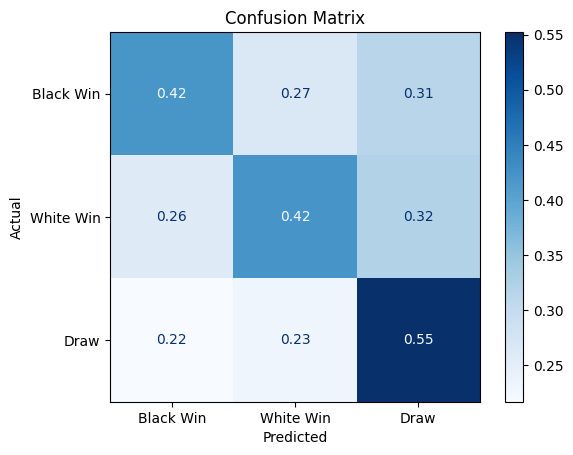

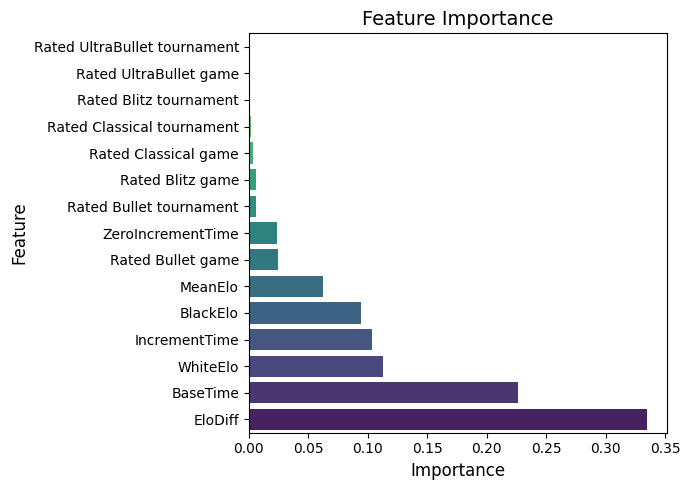

In [13]:
feature_importance = best_forest_clf.feature_importances_.reshape(1, -1)

estimate_baseline_model(
    best_forest_clf, feature_importance, X_train, y_train, X_test, y_test
)

## Gradient Boosting

In [14]:
gradient_boosting_params = {
    "n_estimators": [10, 30, 90],
    "max_depth": [2, 4, 6],
    "max_features": ["sqrt"],
    "learning_rate": [0.1, 0.01],
    "tol": [1e-2],
    "min_samples_split": [1e-3, 1e-4, 1e-5, 1e-6],
    "min_samples_leaf": [1e-3, 1e-4, 1e-5, 1e-6],
    "min_impurity_decrease": [0.0, 1e-3, 1e-4, 1e-5, 1e-6],
    "min_weight_fraction_leaf": [0.0, 1e-3, 1e-4, 1e-5, 1e-6],
}

boosting_clf = GradientBoostingClassifier(verbose=0, validation_fraction=0.1)

random_search = RandomizedSearchCV(
    estimator=boosting_clf,
    param_distributions=gradient_boosting_params,
    n_iter=36,
    cv=5,
    verbose=3,
    random_state=42,
    scoring="balanced_accuracy",
    return_train_score=True,
    n_jobs=-1,
    refit=False,
)

In [ ]:
with mlflow.start_run(run_name="Random Search Boosting") as run:
    random_search_run_id = run.info.run_id
    mlflow.log_param("predict_draws", True)
    
    random_search.fit(X_train, y_train)

In [ ]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

with parallel_backend("multiprocessing"):
    random_search.fit(
        X_train, y_train, sample_weight=sample_weights
    )

In [21]:
print(f"Best Score: {random_search.best_score_}")
print(f"Best Parameters: {random_search.best_params_}")

Best Score: 0.4627381585768898
Best Parameters: {'tol': 0.01, 'n_estimators': 10, 'min_weight_fraction_leaf': 0.0, 'min_samples_split': 1e-05, 'min_samples_leaf': 0.001, 'min_impurity_decrease': 1e-06, 'max_features': 'sqrt', 'max_depth': 6, 'learning_rate': 0.1}


In [22]:
get_worst_params_df(random_search.cv_results_).head(5)

mean_test_score
param_tol param_n_estimators param_min_weight_fraction_leaf param_min_samples_split param_min_samples_leaf param_min_impurity_decrease param_max_features param_max_depth param_learning_rate                 
0.01      10                 0.000100                       0.001000                0.000010               0.00001                     sqrt               2               0.01                        0.442722
                             0.000010                       0.000001                0.000100               0.00000                     sqrt               2               0.01                        0.446293
                             0.000000                       0.000001                0.000001               0.00001                     sqrt               2               0.01                        0.450112
                             0.000001                       0.000010                0.001000               0.00100                     sqrt               2               0.01                        0.451898
                             0.000000                       0.000010                0.000010               0.00100                     sqrt               2               0.10                        0.452039

## Log Best Model

In [ ]:
with mlflow.start_run(run_id=random_search_run_id):
    best_boosting_clf = random_search.best_estimator_
    
    balanced_accuracy = metrics.balanced_accuracy_score(y_test, best_boosting_clf.predict(X_test))
    mlflow.log_metric("balanced_accuracy_X_test", balanced_accuracy)

### Estimate Best Gradient Boosting Model

In [18]:
X_train, y_train, _, _, X_test, y_test = load_train_valid_test(train_sample_size=1)

class_weights = get_class_weights(y_train, verbose=True)

Class weights:
	0-1: 0.6972429817947734
	1-0: 0.6719252445731612
	1/2-1/2: 12.900070154830079


In [19]:
args = {
    "tol": 0.01,
    "n_estimators": 100,
    "min_weight_fraction_leaf": 0.0,
    "min_samples_split": 0.001,
    "min_samples_leaf": 1e-06,
    "min_impurity_decrease": 0.0,
    "max_features": "sqrt",
    "max_depth": 6,
    "learning_rate": 0.1,
    "random_state": BASELINE_RANDOM_STATE,
    "verbose": 3,
}

best_boosting_clf = GradientBoostingClassifier(**args)

In [ ]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

best_boosting_clf = best_boosting_clf.fit(X_train, y_train, sample_weight=sample_weights)

Log Loss on test data: 1.0273
Balanced Accuracy on test data: 47.0%


                                                Classification Report
                         Train Report                                      Validation Report
              precision    recall  f1-score   support         precision    recall  f1-score   support
         0-1       0.60      0.44      0.51    378005              0.60      0.44      0.51     31936
         1-0       0.63      0.42      0.50    392248              0.62      0.42      0.50     33134
     1/2-1/2       0.05      0.59      0.09     20431              0.04      0.55      0.08      1615
    accuracy                           0.44    790684                                  0.43     66685
   macro avg       0.43      0.49      0.37    790684              0.42      0.47      0.36     66685
weighted avg       0.60      0.44      0.50    790684              0.60      0.43      0.49     66685
       


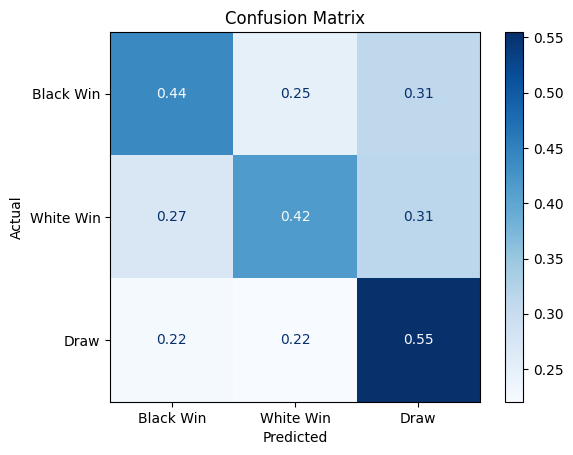

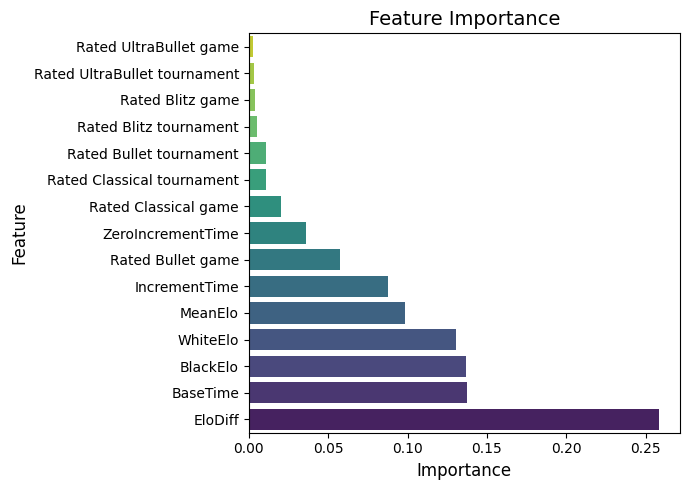

In [22]:
feature_importance = best_boosting_clf.feature_importances_.reshape(1, -1)

estimate_baseline_model(
    best_boosting_clf, feature_importance, X_train, y_train, X_test, y_test
)

## Summary

As expected, ensembles outperformed decision trees. But it takes more time to tune the hyperparameters and train the model.  
Boosting achieved the highest score among the baseline models: 47.0% balanced accuracy. 
